# Uncertainties in Maximum Likelihood Method
Author: Aleksander Filip Żarnecki (University of Warsaw)

### (0) Import libraries 

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

### (1) Define MC experiment

Estimate of mean and sigma from 10 normal distributed measurements

In [2]:
Np=10

# True values for mu and sigma

x0 = 1
sigma0 = 2

# Series of Monte Carlo experiments

def mcexp(Npt=10,Ntry=1):
    vec = np.random.normal(x0,sigma0,size=(Npt,Ntry))
    return np.mean(vec,axis=0),np.std(vec,axis=0)


### (2) Generate experiments and fill result distributions

In [3]:
# Number of generations

Nmc = 1000000

Xval,Sval = mcexp(Np,Nmc)


### (3) Plot results

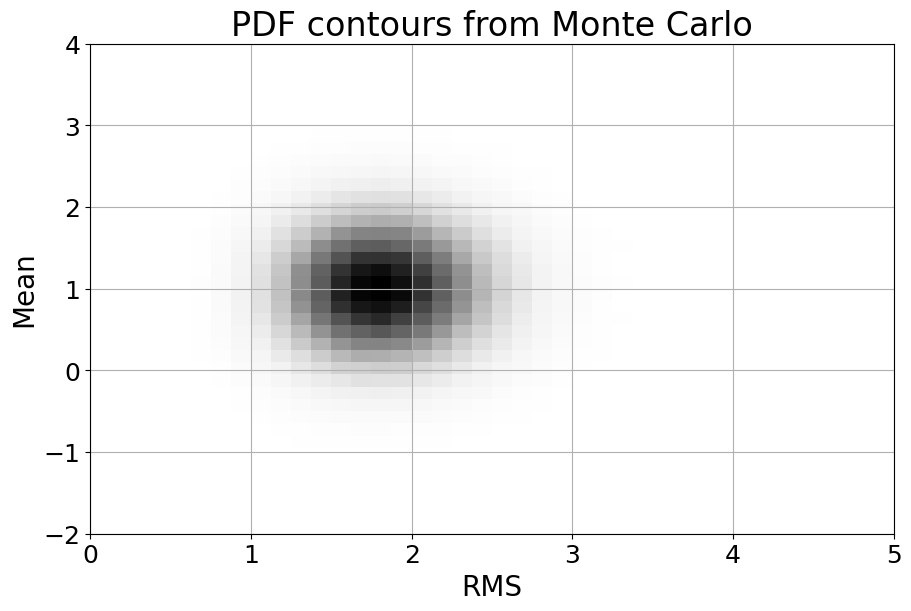

In [4]:
# Create result histograms

Xmin= -2
Xmax=  4
Nxbin = 40

Smin=  0.
Smax=  5.
Nsbin = 40

plt.figure(figsize=(9, 6),layout='constrained')

counts,ybins,xbins,image = plt.hist2d(Sval,Xval, bins=[Nsbin,Nxbin], 
                                      range=[[Smin,Smax],[Xmin,Xmax]],cmap='Greys')

plt.title("PDF contours from Monte Carlo",size=24)
plt.xlabel('RMS',size=20)
plt.ylabel('Mean',size=20)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(which='major', axis='both')


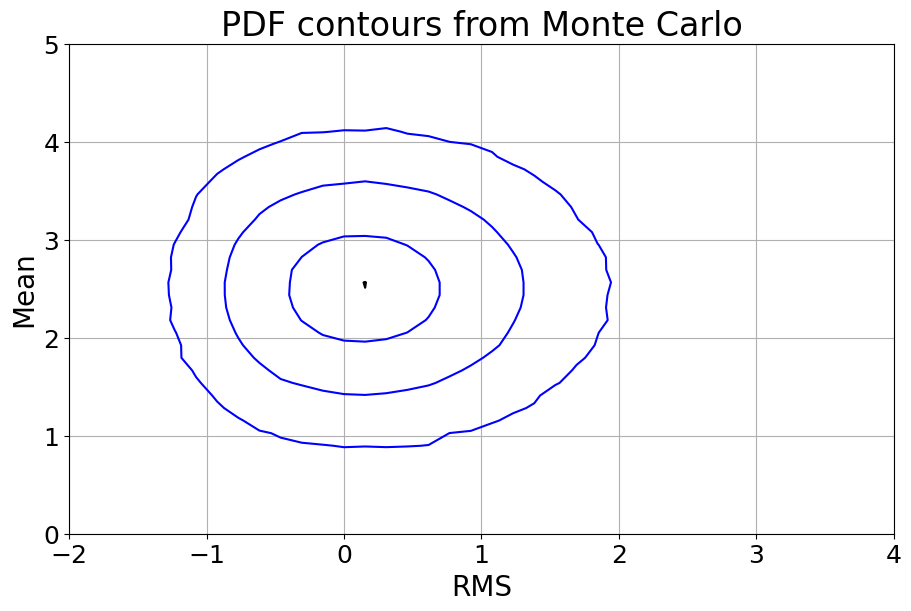

In [5]:
plt.figure(figsize=(9, 6),layout='constrained')

lcounts = np.log(counts+0.1).transpose()     # Logarithmic scale in number of counts
Cmax = np.max(lcounts)

plt.contour(lcounts,extent=[xbins.min(),xbins.max(),ybins.min(),ybins.max()],
            levels=[Cmax-4.5,Cmax-2.,Cmax-0.5,Cmax-0.002],
            colors=['#0000FF', '#0000FF', '#0000FF', '#000000'])

plt.title("PDF contours from Monte Carlo",size=24)
plt.xlabel('RMS',size=20)
plt.ylabel('Mean',size=20)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(which='major', axis='both')

fname = '06_mlm_mc_2d.png'
plt.savefig(fname)